# Módulo 4: Modelado de Tópicos y Tareas de NLU

Descubrir temas latentes en textos sin supervisión, y extraer estructura semántica con NLU.

## 4.1 Modelado de Tópicos (Topic Modeling)

### ¿Qué es LDA?

**Latent Dirichlet Allocation (LDA)** es un modelo generativo probabilístico.

**Supuesto**: cada documento es una mezcla de tópicos, y cada tópico es una distribución de palabras.

```
Documento = mezcla de tópicos
Tópico    = distribución sobre palabras

Ejemplo (K=3 tópicos):
  Doc "The battery lasts all day..."
  → 70% Tópico_Hardware + 20% Tópico_Reseña + 10% Tópico_Precio
```

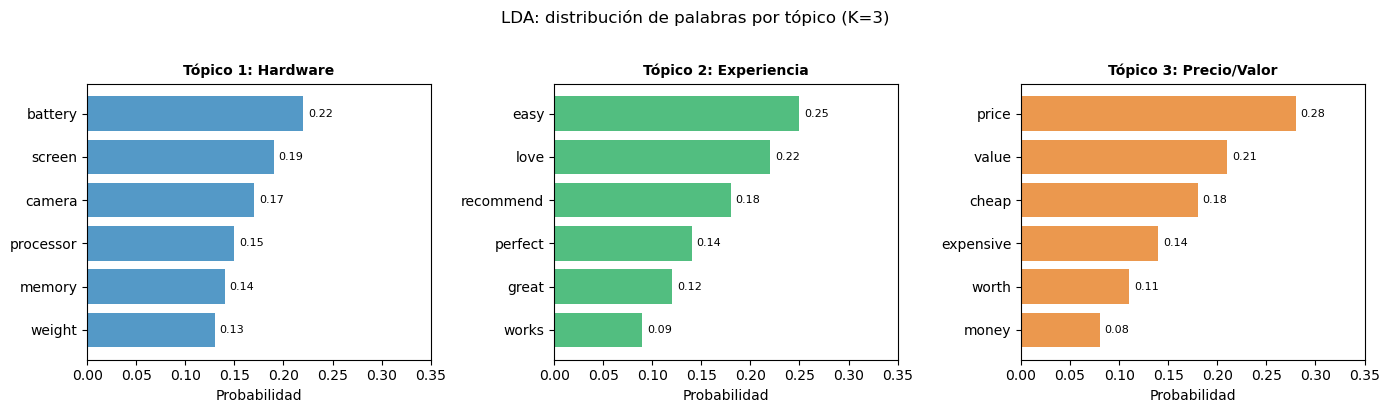

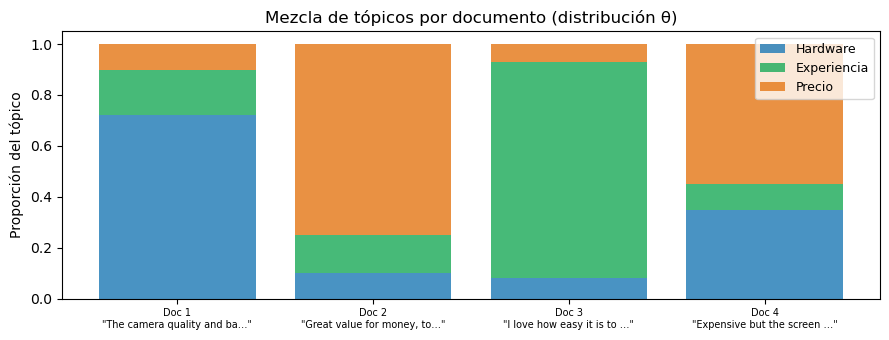

### LDA con Gensim (código de producción)

In [3]:
# Este es el pipeline usado en amazon_topics.py
# (requiere: pip install gensim)

'''
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel

# 1. Preprocesar
token_lists = [cleaner(doc) for doc in raw_texts]

# 2. Construir diccionario
dictionary = corpora.Dictionary(token_lists)
dictionary.filter_extremes(no_below=5, no_above=0.5)

# 3. Convertir a corpus BoW
bow_corpus = [dictionary.doc2bow(tokens) for tokens in token_lists]

# 4. Entrenar LDA
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=10,
    passes=10,
    random_state=42
)

# 5. Ver tópicos
for i, topic in lda_model.print_topics(num_words=8):
    print(f"Tópico {i}: {topic}")

# 6. Coherencia (elegir K óptimo)
cm = CoherenceModel(model=lda_model, texts=token_lists,
                    dictionary=dictionary, coherence='c_v')
print(f"Coherencia c_v: {cm.get_coherence():.4f}")
'''
print("Pipeline LDA — ver amazon_topics.py para implementación completa")

Pipeline LDA — ver amazon_topics.py para implementación completa


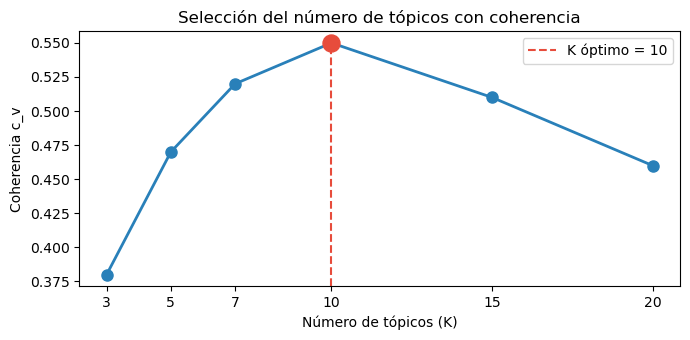

► Elegir K donde la coherencia es máxima antes de decrecer


---
## 4.2 Fundamentos de NLU

### NER — Reconocimiento de Entidades Nombradas

In [5]:
# Ejemplo conceptual de NER (requiere: pip install spacy && python -m spacy download en_core_web_sm)
# Aquí mostramos la salida esperada sin ejecutar spaCy

texto_ner = "Apple CEO Tim Cook announced the iPhone 16 in San Francisco on September 9, 2024."

# Entidades que spaCy detectaría
entidades = [
    ("Apple",         "ORG",       "Organización"),
    ("Tim Cook",      "PERSON",    "Persona"),
    ("iPhone 16",     "PRODUCT",   "Producto"),
    ("San Francisco", "GPE",       "Lugar geográfico"),
    ("September 9, 2024", "DATE", "Fecha"),
]

print(f"Texto: {texto_ner}\n")
print(f"{'Entidad':<25} {'Tipo':<10} {'Descripción'}")
print("-" * 55)
for ent, tipo, desc in entidades:
    print(f"{ent:<25} {tipo:<10} {desc}")

Texto: Apple CEO Tim Cook announced the iPhone 16 in San Francisco on September 9, 2024.

Entidad                   Tipo       Descripción
-------------------------------------------------------
Apple                     ORG        Organización
Tim Cook                  PERSON     Persona
iPhone 16                 PRODUCT    Producto
San Francisco             GPE        Lugar geográfico
September 9, 2024         DATE       Fecha


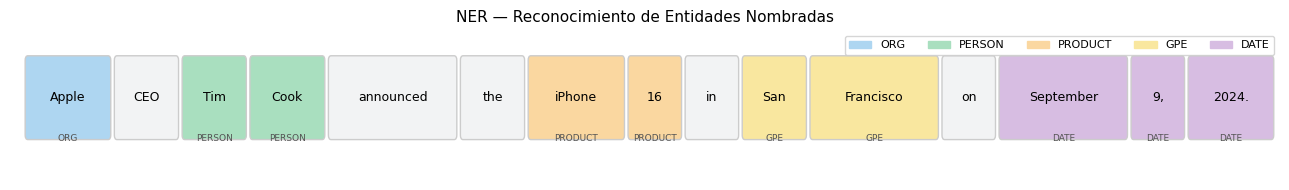

### POS Tagging — Etiquetado de Partes del Discurso

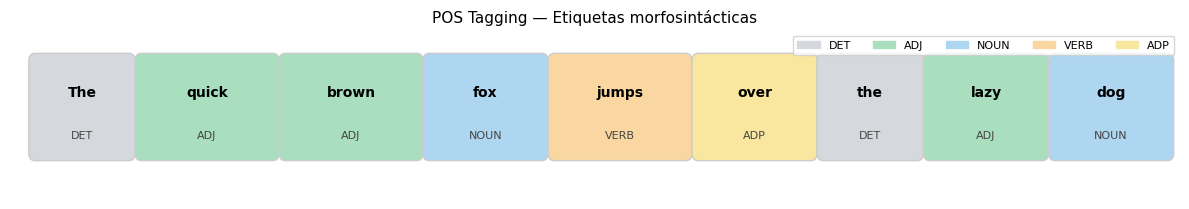


Etiquetas universales más comunes:
  NOUN     Sustantivo
  VERB     Verbo
  ADJ      Adjetivo
  ADV      Adverbio
  DET      Determinante
  PROPN    Nombre propio
  PRON     Pronombre
  ADP      Preposición


### Análisis de Dependencias

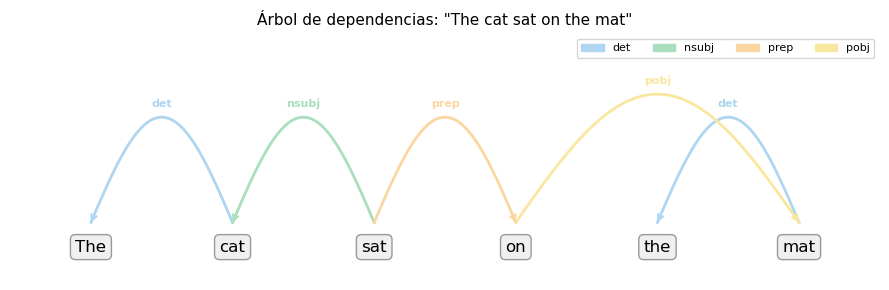

---
## Resumen del Módulo 4

| Tarea | Herramienta en el proyecto | Para qué sirve |
|-------|---------------------------|----------------|
| **Topic Modeling (LDA)** | `amazon_topics.py` | Descubrir temas en reseñas sin etiquetas |
| **NER** | `amazon_nlu.py` + spaCy | Extraer marcas, productos, fechas |
| **POS Tagging** | spaCy (`preprocessing.py`) | Filtrar por tipo de palabra |
| **Dependencias** | spaCy | Extraer relaciones sujeto-verbo-objeto |

```python
# spaCy hace las tres tareas con un solo objeto doc
import spacy
nlp = spacy.load('en_core_web_sm')
doc = nlp("Apple CEO Tim Cook launched the iPhone")
for ent in doc.ents: print(ent.text, ent.label_)   # NER
for tok in doc:      print(tok.text, tok.pos_)      # POS
for tok in doc:      print(tok.text, tok.dep_)      # Dependencias
```